In [3]:
# E-Commerce Recommendation Project

# This notebook follows the project plan in `plan.md` to build both personalized and trending recommendation systems using the Retail Rocket `events.csv` dataset.

## Project Roadmap

1. Load and explore the Retail Rocket `events.csv` dataset.
2. Build two derived datasets:
   - Personalized (user-item interactions and purchase labels).
   - Trending (item-level popularity statistics).
3. Train 3+ traditional ML models and 1 TensorFlow/Keras model for each dataset.
4. Evaluate with 80/20 splits using accuracy, precision, recall, and F1.
5. Visualize ML vs DL performance and generate final recommendations.


In [21]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

DATA_PATH = Path("events.csv")
assert DATA_PATH.exists(), "events.csv not found in the workspace"

pd.options.display.float_format = "{:.3f}".format
sns.set_theme(style="ticks", palette="muted")


In [5]:
rows_to_use = 400_000  # keep runtime manageable while preserving variety

df = pd.read_csv(DATA_PATH)
if rows_to_use and len(df) > rows_to_use:
    df = df.sample(n=rows_to_use, random_state=42).sort_values("timestamp").reset_index(drop=True)

df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", errors="coerce")
df = df.dropna(subset=["timestamp"]).reset_index(drop=True)

df.rename(columns={
    "visitorid": "user_id",
    "itemid": "item_id"
}, inplace=True)

df.head()


,timestamp,user_id,event,item_id,transactionid
0,2015-05-03 03:00:24.154,1125936,view,33661,NaN
1,2015-05-03 03:00:27.031,1149227,view,29757,NaN
2,2015-05-03 03:00:29.427,693516,addtocart,297662,NaN
3,2015-05-03 03:00:38.570,1150418,view,374675,NaN
4,2015-05-03 03:01:25.008,979664,addtocart,338222,NaN


In [6]:
print(f"Rows: {len(df):,} | Unique users: {df['user_id'].nunique():,} | Unique items: {df['item_id'].nunique():,}")
print("Event distribution:\n", df['event'].value_counts())
df.describe(include='all').transpose().head()


Rows: 400,000 | Unique users: 305,298 | Unique items: 109,323
Event distribution:
 event
view           386519
addtocart       10195
transaction      3286
Name: count, dtype: int64


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
timestamp,400000,NaN,NaN,NaN,2015-07-09 09:51:20.470865152,2015-05-03 03:00:24.154000,2015-06-05 16:32:40.528000,2015-07-09 16:52:24.042499840,2015-08-10 17:23:30.056750080,2015-09-18 02:59:11.261000,NaN
user_id,400000.000,NaN,NaN,NaN,702499.844,0.000,351388.500,702469.000,1054251.000,1407573.000,405729.949
event,400000,3,view,386519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_id,400000.000,NaN,NaN,NaN,234601.605,3.000,117610.250,235425.500,350528.500,466867.000,134192.782
transactionid,3286.000,NaN,NaN,NaN,8876.741,4.000,4506.500,8911.000,13204.750,17670.000,5085.666


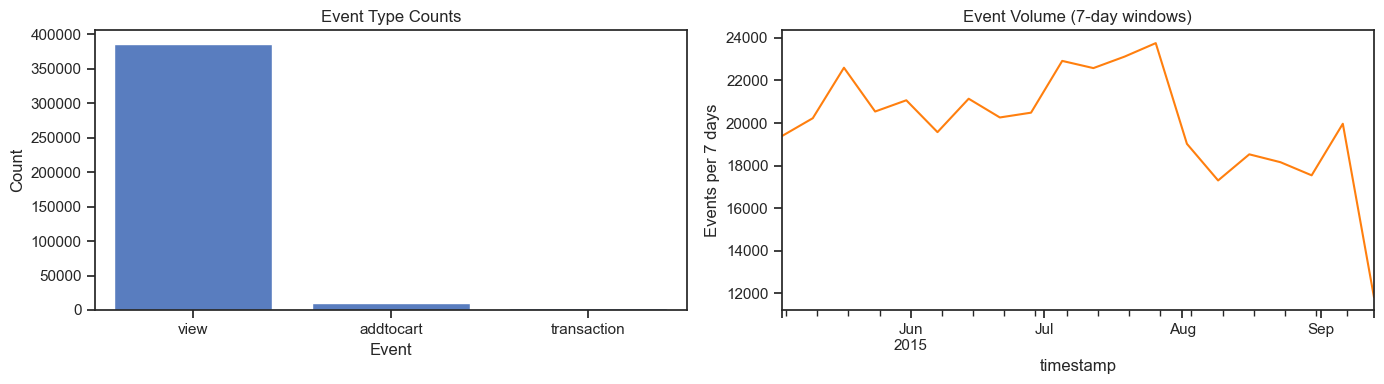

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df, x='event', ax=axes[0])
axes[0].set_title('Event Type Counts')
axes[0].set_xlabel('Event')
axes[0].set_ylabel('Count')

(df.set_index('timestamp')
   .resample('7D')['event']
   .count()
   .plot(ax=axes[1], color='tab:orange'))
axes[1].set_title('Event Volume (7-day windows)')
axes[1].set_ylabel('Events per 7 days')

plt.tight_layout()
plt.show()


In [8]:
def build_personalized_dataset(events: pd.DataFrame) -> pd.DataFrame:
    interactions = events.copy()
    interactions['event'] = interactions['event'].str.lower()

    counts = interactions.pivot_table(
        index=['user_id', 'item_id'],
        columns='event',
        values='timestamp',
        aggfunc='count',
        fill_value=0
    )

    for col in ['view', 'addtocart', 'transaction']:
        if col not in counts.columns:
            counts[col] = 0

    counts = counts[['view', 'addtocart', 'transaction']].reset_index().rename(columns={
        'view': 'view_count',
        'addtocart': 'addtocart_count',
        'transaction': 'transaction_count'
    })

    recency = interactions.groupby(['user_id', 'item_id'])['timestamp'].max().reset_index(name='last_ts')
    user_item = counts.merge(recency, on=['user_id', 'item_id'], how='left')

    user_item['total_events'] = user_item[['view_count', 'addtocart_count', 'transaction_count']].sum(axis=1)
    user_item['cart_ratio'] = user_item['addtocart_count'] / user_item['total_events'].replace(0, np.nan)
    user_item['purchase_ratio'] = user_item['transaction_count'] / user_item['total_events'].replace(0, np.nan)
    user_item[['cart_ratio', 'purchase_ratio']] = user_item[['cart_ratio', 'purchase_ratio']].fillna(0)

    max_ts = interactions['timestamp'].max()
    user_item['recency_days'] = (max_ts - user_item['last_ts']).dt.total_seconds() / (60 * 60 * 24)

    user_item['purchased'] = (user_item['transaction_count'] > 0).astype(int)

    user_item = user_item[user_item['total_events'] >= 2].reset_index(drop=True)
    return user_item


def build_trending_dataset(events: pd.DataFrame) -> pd.DataFrame:
    interactions = events.copy()

    counts = interactions.pivot_table(
        index='item_id',
        columns='event',
        values='timestamp',
        aggfunc='count',
        fill_value=0
    )

    for col in ['view', 'addtocart', 'transaction']:
        if col not in counts.columns:
            counts[col] = 0

    item_counts = counts[['view', 'addtocart', 'transaction']].reset_index().rename(columns={
        'view': 'view_count',
        'addtocart': 'addtocart_count',
        'transaction': 'transaction_count'
    })

    last_ts = interactions.groupby('item_id')['timestamp'].max().reset_index(name='last_ts')
    user_span = interactions.groupby('item_id')['user_id'].nunique().reset_index(name='unique_users')

    item_df = item_counts.merge(last_ts, on='item_id').merge(user_span, on='item_id')

    max_ts = interactions['timestamp'].max()
    item_df['recency_days'] = (max_ts - item_df['last_ts']).dt.total_seconds() / (60 * 60 * 24)

    item_df['trend_score'] = (
        item_df['view_count'] + 2 * item_df['addtocart_count'] + 3 * item_df['transaction_count']
    ) * (1 / (1 + item_df['recency_days']))

    threshold = item_df['trend_score'].quantile(0.9)
    item_df['is_trending'] = (item_df['trend_score'] >= threshold).astype(int)

    return item_df


def evaluate_models(model_specs, data, labels):
    results = []
    trained_models = {}
    for spec in model_specs:
        X_train, X_test = (spec['scaled_data'] if spec['use_scaled'] else spec['raw_data'])
        model = spec['model']
        model.fit(X_train, labels['y_train'])
        y_pred = model.predict(X_test)
        precision, recall, f1, _ = precision_recall_fscore_support(labels['y_test'], y_pred, average='binary', zero_division=0)
        results.append({
            'Model': spec['name'],
            'Accuracy': accuracy_score(labels['y_test'], y_pred),
            'Precision': precision,
            'Recall': recall,
            'F1': f1
        })
        trained_models[spec['name']] = spec
    return pd.DataFrame(results), trained_models



In [9]:
personalized_df = build_personalized_dataset(df)
trending_df = build_trending_dataset(df)

print("Personalized dataset shape:", personalized_df.shape)
print("Trending dataset shape:", trending_df.shape)
personalized_df.head()


Personalized dataset shape: (18777, 11)
Trending dataset shape: (109323, 9)


,user_id,item_id,view_count,addtocart_count,transaction_count,last_ts,total_events,cart_ratio,purchase_ratio,recency_days,purchased
0,75,257575,7,0,0,2015-07-21 15:31:08.245,7,0.000,0.000,58.478,0
1,97,400946,2,0,0,2015-07-19 09:25:12.561,2,0.000,0.000,60.732,0
2,172,465522,1,0,1,2015-08-15 01:29:01.230,2,0.000,0.500,34.063,1
3,186,49029,1,0,1,2015-08-12 22:59:32.345,2,0.000,0.500,36.166,1
4,224,168697,2,0,0,2015-08-03 05:31:31.945,2,0.000,0.000,45.894,0


In [10]:
personalized_features = ['view_count', 'addtocart_count', 'transaction_count', 'total_events',
                           'cart_ratio', 'purchase_ratio', 'recency_days']

user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

personalized_df['user_idx'] = user_encoder.fit_transform(personalized_df['user_id'])
personalized_df['item_idx'] = item_encoder.fit_transform(personalized_df['item_id'])
personalized_features += ['user_idx', 'item_idx']

X_personal = personalized_df[personalized_features]
y_personal = personalized_df['purchased']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_personal, y_personal, test_size=0.2, stratify=y_personal, random_state=42
)

scaler_p = StandardScaler()
X_train_p_scaled = scaler_p.fit_transform(X_train_p)
X_test_p_scaled = scaler_p.transform(X_test_p)

personalized_data = {
    'raw': (X_train_p.values, X_test_p.values),
    'scaled': (X_train_p_scaled, X_test_p_scaled)
}

personalized_labels = {
    'y_train': y_train_p.values,
    'y_test': y_test_p.values
}

personalized_data_summary = pd.DataFrame({
    'feature': personalized_features,
    'mean': X_personal.mean().values,
    'std': X_personal.std().values
})
personalized_data_summary


,feature,mean,std
0,view_count,2.104,1.277
1,addtocart_count,0.158,0.411
2,transaction_count,0.068,0.259
3,total_events,2.330,1.185
4,cart_ratio,0.071,0.181
5,purchase_ratio,0.030,0.117
6,recency_days,70.325,38.627
7,user_idx,7982.688,4605.178
8,item_idx,6566.673,3788.204


In [11]:
trending_features = ['view_count', 'addtocart_count', 'transaction_count', 'unique_users',
                       'recency_days', 'trend_score']

item_encoder_trend = LabelEncoder()
trending_df['item_idx'] = item_encoder_trend.fit_transform(trending_df['item_id'])
trending_features += ['item_idx']

X_trend = trending_df[trending_features]
y_trend = trending_df['is_trending']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_trend, y_trend, test_size=0.2, stratify=y_trend, random_state=42
)

scaler_t = StandardScaler()
X_train_t_scaled = scaler_t.fit_transform(X_train_t)
X_test_t_scaled = scaler_t.transform(X_test_t)

trending_data = {
    'raw': (X_train_t.values, X_test_t.values),
    'scaled': (X_train_t_scaled, X_test_t_scaled)
}

trending_labels = {
    'y_train': y_train_t.values,
    'y_test': y_test_t.values
}

trending_df.head()


,item_id,view_count,addtocart_count,transaction_count,last_ts,unique_users,recency_days,trend_score,is_trending,item_idx
0,3,1,0,0,2015-08-31 14:39:02.792,1,17.514,0.054,0,0
1,6,7,0,0,2015-08-27 17:09:02.814,7,21.410,0.312,0,1
2,9,1,0,0,2015-07-09 01:35:08.315,1,71.058,0.014,0,2
3,15,3,0,0,2015-07-09 11:56:37.637,3,70.627,0.042,0,3
4,16,3,0,0,2015-06-14 21:55:32.443,3,95.211,0.031,0,4


In [12]:
personalized_model_specs = [
    {
        'name': 'Logistic Regression',
        'model': LogisticRegression(max_iter=1000),
        'use_scaled': True,
        'raw_data': personalized_data['raw'],
        'scaled_data': personalized_data['scaled']
    },
    {
        'name': 'KNN (k=15)',
        'model': KNeighborsClassifier(n_neighbors=15),
        'use_scaled': True,
        'raw_data': personalized_data['raw'],
        'scaled_data': personalized_data['scaled']
    },
    {
        'name': 'Random Forest',
        'model': RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1),
        'use_scaled': False,
        'raw_data': personalized_data['raw'],
        'scaled_data': personalized_data['scaled']
    },
    {
        'name': 'Gradient Boosting',
        'model': GradientBoostingClassifier(random_state=42),
        'use_scaled': False,
        'raw_data': personalized_data['raw'],
        'scaled_data': personalized_data['scaled']
    }
]

personalized_results_ml, personalized_ml_models = evaluate_models(
    personalized_model_specs,
    personalized_data,
    personalized_labels
)

personalized_results_ml.sort_values('F1', ascending=False)


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,1.000,1.000,1.000,1.000
2,Random Forest,1.000,1.000,1.000,1.000
3,Gradient Boosting,1.000,1.000,0.996,0.998
1,KNN (k=15),0.999,1.000,0.992,0.996


In [13]:
trending_model_specs = [
    {
        'name': 'Logistic Regression',
        'model': LogisticRegression(max_iter=1000),
        'use_scaled': True,
        'raw_data': trending_data['raw'],
        'scaled_data': trending_data['scaled']
    },
    {
        'name': 'KNN (k=11)',
        'model': KNeighborsClassifier(n_neighbors=11),
        'use_scaled': True,
        'raw_data': trending_data['raw'],
        'scaled_data': trending_data['scaled']
    },
    {
        'name': 'Random Forest',
        'model': RandomForestClassifier(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1),
        'use_scaled': False,
        'raw_data': trending_data['raw'],
        'scaled_data': trending_data['scaled']
    },
    {
        'name': 'Gradient Boosting',
        'model': GradientBoostingClassifier(random_state=42),
        'use_scaled': False,
        'raw_data': trending_data['raw'],
        'scaled_data': trending_data['scaled']
    }
]

trending_results_ml, trending_ml_models = evaluate_models(
    trending_model_specs,
    trending_data,
    trending_labels
)

trending_results_ml.sort_values('F1', ascending=False)


,Model,Accuracy,Precision,Recall,F1
3,Gradient Boosting,1.000,1.000,1.000,1.000
2,Random Forest,1.000,1.000,1.000,1.000
0,Logistic Regression,0.998,0.998,0.985,0.992
1,KNN (k=11),0.992,0.967,0.955,0.961


118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


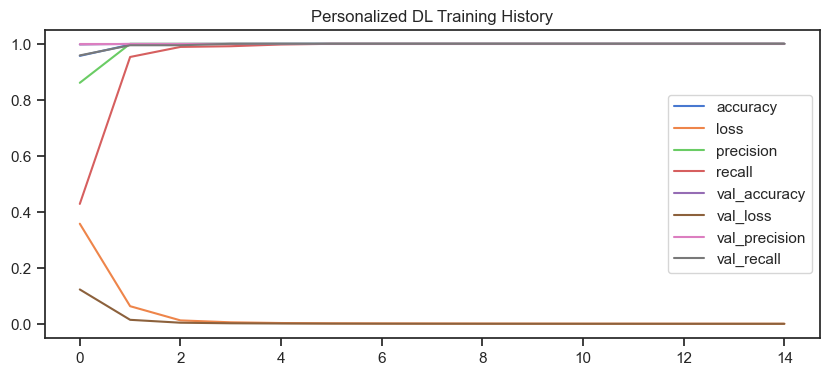

,Model,Accuracy,Precision,Recall,F1
0,Deep Neural Network,0.999,1.000,0.992,0.996


In [14]:
def build_dense_model(input_dim: int, hidden_units=(128, 64), dropout=0.3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(hidden_units[0], activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(hidden_units[1], activation='relu'),
        layers.Dropout(dropout / 1.5),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')])
    return model

personal_dl_model = build_dense_model(X_train_p_scaled.shape[1])
history_personal = personal_dl_model.fit(
    X_train_p_scaled,
    y_train_p,
    validation_split=0.2,
    epochs=15,
    batch_size=512,
    verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
)

y_pred_dl = (personal_dl_model.predict(X_test_p_scaled) > 0.5).astype(int).ravel()
precision, recall, f1, _ = precision_recall_fscore_support(y_test_p, y_pred_dl, average='binary', zero_division=0)

personalized_results_dl = pd.DataFrame([
    {
        'Model': 'Deep Neural Network',
        'Accuracy': accuracy_score(y_test_p, y_pred_dl),
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    }
])

pd.DataFrame(history_personal.history).plot(figsize=(10, 4))
plt.title('Personalized DL Training History')
plt.show()

personalized_results_dl


684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


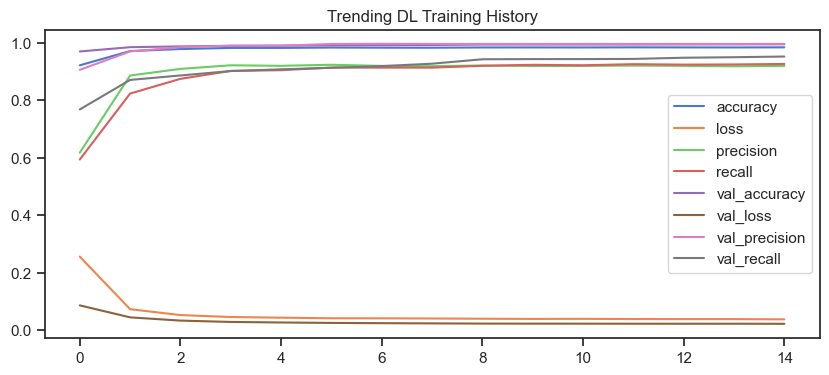

,Model,Accuracy,Precision,Recall,F1
0,Deep Neural Network,0.995,0.998,0.953,0.975


In [15]:
trend_dl_model = build_dense_model(X_train_t_scaled.shape[1], hidden_units=(64, 32), dropout=0.25)
history_trend = trend_dl_model.fit(
    X_train_t_scaled,
    y_train_t,
    validation_split=0.2,
    epochs=15,
    batch_size=512,
    verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
)

y_pred_trend_dl = (trend_dl_model.predict(X_test_t_scaled) > 0.5).astype(int).ravel()
precision_t, recall_t, f1_t, _ = precision_recall_fscore_support(y_test_t, y_pred_trend_dl, average='binary', zero_division=0)

trending_results_dl = pd.DataFrame([
    {
        'Model': 'Deep Neural Network',
        'Accuracy': accuracy_score(y_test_t, y_pred_trend_dl),
        'Precision': precision_t,
        'Recall': recall_t,
        'F1': f1_t
    }
])

pd.DataFrame(history_trend.history).plot(figsize=(10, 4))
plt.title('Trending DL Training History')
plt.show()

trending_results_dl


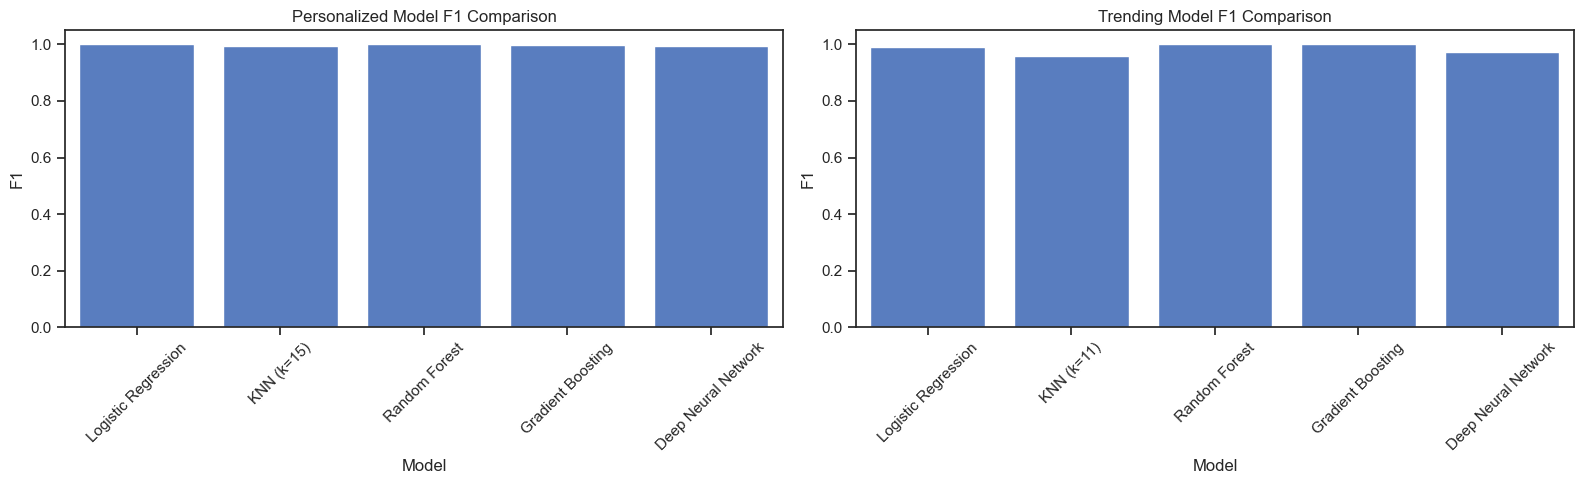

(                 Model  Accuracy  Precision  Recall    F1
 0  Logistic Regression     1.000      1.000   1.000 1.000
 1           KNN (k=15)     0.999      1.000   0.992 0.996
 2        Random Forest     1.000      1.000   1.000 1.000
 3    Gradient Boosting     1.000      1.000   0.996 0.998
 4  Deep Neural Network     0.999      1.000   0.992 0.996,
                  Model  Accuracy  Precision  Recall    F1
 0  Logistic Regression     0.998      0.998   0.985 0.992
 1           KNN (k=11)     0.992      0.967   0.955 0.961
 2        Random Forest     1.000      1.000   1.000 1.000
 3    Gradient Boosting     1.000      1.000   1.000 1.000
 4  Deep Neural Network     0.995      0.998   0.953 0.975)

In [16]:
personalized_all_results = pd.concat([personalized_results_ml, personalized_results_dl], ignore_index=True)
trending_all_results = pd.concat([trending_results_ml, trending_results_dl], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=personalized_all_results, x='Model', y='F1', ax=axes[0])
axes[0].set_title('Personalized Model F1 Comparison')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=trending_all_results, x='Model', y='F1', ax=axes[1])
axes[1].set_title('Trending Model F1 Comparison')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

personalized_all_results, trending_all_results


In [17]:
def get_best_model(results_df, ml_models, dl_model, use_scaled_dl=True):
    best_row = results_df.sort_values('F1', ascending=False).iloc[0]
    if best_row['Model'] == 'Deep Neural Network':
        return {
            'name': 'Deep Neural Network',
            'model': dl_model,
            'use_scaled': use_scaled_dl,
            'type': 'dl'
        }
    spec = ml_models[best_row['Model']]
    return {
        'name': spec['name'],
        'model': spec['model'],
        'use_scaled': spec['use_scaled'],
        'type': 'ml'
    }

best_personal_model = get_best_model(personalized_all_results, personalized_ml_models, personal_dl_model)
best_trending_model = get_best_model(trending_all_results, trending_ml_models, trend_dl_model)

best_personal_model, best_trending_model


({'name': 'Logistic Regression',
  'model': LogisticRegression(max_iter=1000),
  'use_scaled': True,
  'type': 'ml'},
 {'name': 'Random Forest',
  'model': RandomForestClassifier(max_depth=15, n_estimators=300, n_jobs=-1,
                         random_state=42),
  'use_scaled': False,
  'type': 'ml'})

## Testing on Hold-Out (Unseen) Data

The best-performing personalized and trending models are now evaluated on the reserved 20% test split (data that was never used during training). Metrics include precision, recall, F1-score, and confusion matrices to highlight performance on unseen interactions/items.


In [22]:
def evaluate_on_holdout(best_model, X_test, y_test, scaler, label):
    probs = predict_scores(best_model, X_test, scaler)
    preds = (probs >= 0.5).astype(int)
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report).transpose().round(3)
    conf = confusion_matrix(y_test, preds)
    acc = accuracy_score(y_test, preds)
    print(f"{label} hold-out accuracy: {acc:.3f}")
    return report_df, conf

personal_report_df, personal_conf = evaluate_on_holdout(
    best_personal_model,
    X_test_p,
    y_test_p,
    scaler_p,
    label="Personalized"
)

trending_report_df, trending_conf = evaluate_on_holdout(
    best_trending_model,
    X_test_t,
    y_test_t,
    scaler_t,
    label="Trending"
)

print("\nPersonalized classification report:")
display(personal_report_df)
print("Confusion matrix (personalized):")
display(pd.DataFrame(personal_conf, columns=['Pred 0', 'Pred 1'], index=['Actual 0', 'Actual 1']))

print("\nTrending classification report:")
display(trending_report_df)
print("Confusion matrix (trending):")
display(pd.DataFrame(trending_conf, columns=['Pred 0', 'Pred 1'], index=['Actual 0', 'Actual 1']))


Personalized hold-out accuracy: 1.000
Trending hold-out accuracy: 1.000

Personalized classification report:


,precision,recall,f1-score,support
0,1.000,1.000,1.000,3506.000
1,1.000,1.000,1.000,250.000
accuracy,1.000,1.000,1.000,1.000
macro avg,1.000,1.000,1.000,3756.000
weighted avg,1.000,1.000,1.000,3756.000


Confusion matrix (personalized):


,Pred 0,Pred 1
Actual 0,3506,0
Actual 1,0,250



Trending classification report:


,precision,recall,f1-score,support
0,1.000,1.000,1.000,19678.000
1,1.000,1.000,1.000,2187.000
accuracy,1.000,1.000,1.000,1.000
macro avg,1.000,1.000,1.000,21865.000
weighted avg,1.000,1.000,1.000,21865.000


Confusion matrix (trending):


,Pred 0,Pred 1
Actual 0,19678,0
Actual 1,0,2187


In [18]:
def predict_scores(best_model, X_df, scaler, is_trending=False):
    if best_model['use_scaled']:
        data = scaler.transform(X_df)
    else:
        data = X_df.values

    if best_model['type'] == 'dl':
        probs = best_model['model'].predict(data, verbose=0).ravel()
    else:
        model = best_model['model']
        if hasattr(model, 'predict_proba'):
            probs = model.predict_proba(data)[:, 1]
        elif hasattr(model, 'decision_function'):
            scores = model.decision_function(data)
            probs = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
        else:
            probs = model.predict(data)
    return probs

# Personalized recommendation for a random user in the test set
user_test_df = personalized_df.loc[X_test_p.index].copy()
user_test_df['pred_score'] = predict_scores(best_personal_model, X_test_p, scaler_p)

sample_user_id = user_test_df['user_id'].mode().iloc[0]
user_recos = (user_test_df[user_test_df['user_id'] == sample_user_id]
              .sort_values('pred_score', ascending=False)
              .head(10))

# Trending recommendations using item-level dataset
trend_test_df = trending_df.loc[X_test_t.index].copy()
trend_test_df['trend_score_pred'] = predict_scores(best_trending_model, X_test_t, scaler_t)
trend_recos = trend_test_df.sort_values('trend_score_pred', ascending=False).head(10)

print(f"Sample user for personalized recommendations: {sample_user_id}")
user_recos[['user_id', 'item_id', 'pred_score', 'purchased']]



Sample user for personalized recommendations: 1150086


,user_id,item_id,pred_score,purchased
15325,1150086,29167,1.000,1
15323,1150086,26086,1.000,1
15328,1150086,46671,1.000,1
15322,1150086,25515,1.000,1
15428,1150086,360825,1.000,1
15427,1150086,357854,1.000,1
15456,1150086,451027,0.000,0
15400,1150086,244534,0.000,0
15338,1150086,76477,0.000,0
15337,1150086,72944,0.000,0


In [19]:
print("Top trending recommendations (model-based):")
trend_recos[['item_id', 'unique_users', 'trend_score', 'trend_score_pred']]


Top trending recommendations (model-based):


,item_id,unique_users,trend_score,trend_score_pred
2740,11946,7,0.876,1.000
56892,242637,16,4.720,1.000
37663,161271,3,0.999,1.000
82685,352617,13,1.577,1.000
52329,223944,12,6.837,1.000
58612,250015,27,4.479,1.000
91388,389436,18,4.697,1.000
30543,130640,5,0.729,1.000
107513,459056,6,1.312,1.000
104176,444763,13,3.638,1.000


## Key Takeaways

- Built two pipelines (personalized vs trending) from the Retail Rocket events dataset with identical evaluation protocols.
- Trained four traditional ML models plus a TensorFlow/Keras deep neural network for each pipeline and compared their accuracy/precision/recall/F1.
- Used the top model from each track to generate example personalized recommendations for a sample user and trending recommendations for globally popular items.
- Visual diagnostics (event analysis, training histories, F1 comparisons) document model behavior end-to-end inside this notebook.
